## 1. agent 패키지 불러오기

`nodes.py`가 모듈을 불러오는 시점에 `ChatClovaX(...)`를 바로 생성하기 때문에,
`CLOVASTUDIO_API_KEY`가 환경변수에 없으면 import 자체가 에러로 끝납니다.

아직 키를 발급받기 전이라면, 그림을 그리는 용도로만 쓸 더미 값을 넣어둡니다.
실제로 CLOVA X에 요청을 보내는 게 아니라 그래프 구조만 조립하는 것이므로,
가짜 키를 넣어도 이 노트북의 목적에는 문제가 없습니다.
키를 이미 발급받으셨다면 이 셀은 건드리지 않아도 됩니다. (이미 설정된 진짜 키를 덮어쓰지 않습니다.)

In [1]:
import os
import sys

# 노트북이 project-root에 있고, 바로 옆에 agent/ 폴더가 있다고 가정합니다.
# 다른 위치에서 이 노트북을 연다면 아래 경로를 실제 project-root로 바꿔주세요.
sys.path.insert(0, os.path.abspath("."))

# .env가 이 노트북과 같은 위치에 있으므로 바로 읽는다. 아래 import 순간에
# agent.node가 ChatClovaX(...)를 딱 한 번 만드는데, 그때의 CLOVASTUDIO_API_KEY
# 값을 그대로 들고 있게 되므로, import보다 반드시 먼저 읽어야 한다.
from dotenv import load_dotenv
load_dotenv()

# 지금 이 시점의 키가 실제 CLOVA 키(nv-로 시작)인지 바로 확인한다.
_key = os.environ.get("CLOVASTUDIO_API_KEY", "")
if _key.startswith("nv-"):
    print("CLOVASTUDIO_API_KEY: 실제 CLOVA API 키로 보입니다 (nv-로 시작)")
else:
    print(f"CLOVASTUDIO_API_KEY: nv-로 시작하지 않는 값입니다. .env 파일을 확인해보세요 (앞 6자: {_key[:6]!r})")

from agent.graph import build_graph
from agent.engines import EngineRegistry, RdbHttpEngine, GraphDbHttpEngine, VectorHttpEngine

print("import 완료")


CLOVASTUDIO_API_KEY: 실제 CLOVA API 키로 보입니다 (nv-로 시작)
import 완료


## 2. 그래프 조립

세 엔진 클래스를 실제로 생성합니다. 이 시점에는 서버로 아무 요청도 나가지 않습니다.
`RdbHttpEngine()` 같은 생성자는 접속 준비만 할 뿐, 실제 통신은 노드가 실행될 때(`.query()`,
`.search()` 호출 시점)에만 일어납니다. 그러니 아직 서버 접속 정보가 정확하지 않아도
그래프 구조를 확인하는 데는 지장이 없습니다.

In [2]:
engines = EngineRegistry(
    rdb=RdbHttpEngine(),
    graph=GraphDbHttpEngine(),
    vector=VectorHttpEngine(),
)

app = build_graph(engines)
g = app.get_graph()

print("노드 목록:", list(g.nodes.keys()))

노드 목록: ['__start__', 'plan_routing', 'dispatch', 'graph_node', 'rdb_node', 'vector_node', 'combine_db_results', 'generate_answer', 'format_abstain', '__end__']


## 3. mermaid 텍스트로 보기 (네트워크 불필요)

아래 셀의 출력을 그대로 복사해서 [mermaid.live](https://mermaid.live) 에 붙여넣으면
바로 그림으로 볼 수 있습니다. 기술제안서에 넣을 흐름도로도 그대로 쓸 수 있습니다.

In [3]:
mermaid_text = g.draw_mermaid()
print(mermaid_text)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	plan_routing(plan_routing)
	dispatch(dispatch)
	graph_node(graph_node)
	rdb_node(rdb_node)
	vector_node(vector_node)
	combine_db_results(combine_db_results)
	generate_answer(generate_answer)
	format_abstain(format_abstain)
	__end__([<p>__end__</p>]):::last
	__start__ --> plan_routing;
	combine_db_results --> generate_answer;
	dispatch -.-> combine_db_results;
	dispatch -.-> graph_node;
	dispatch -.-> rdb_node;
	dispatch -.-> vector_node;
	graph_node --> dispatch;
	plan_routing -.-> dispatch;
	plan_routing -.-> format_abstain;
	rdb_node --> dispatch;
	vector_node --> dispatch;
	format_abstain --> __end__;
	generate_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 4. 노트북 안에 텍스트로 바로 그리기 (네트워크 불필요)

`grandalf` 패키지만 있으면 되고, 외부 서버를 거치지 않습니다.
VM에서 외부 API 호출이 막혀 있을 가능성이 있다면 이 방법이 가장 안전합니다.

In [4]:
print(g.draw_ascii())

                                                      +-----------+                                                          
                                                      | __start__ |                                                          
                                                      +-----------+                                                          
                                                             *                                                               
                                                             *                                                               
                                                             *                                                               
                                                     +--------------+                                                        
                                                     | plan_routing |.....                                            

## 5. PNG 이미지로 노트북에 바로 표시 (인터넷 필요)

`draw_mermaid_png()`는 mermaid.ink라는 외부 API를 거쳐서 이미지를 만듭니다.
인터넷이 막혀 있는 환경이면 이 셀만 실패하고, 위의 두 방법은 영향받지 않습니다.
성공하면 `graph.png` 파일로도 저장되고, 노트북 화면에 바로 표시됩니다.

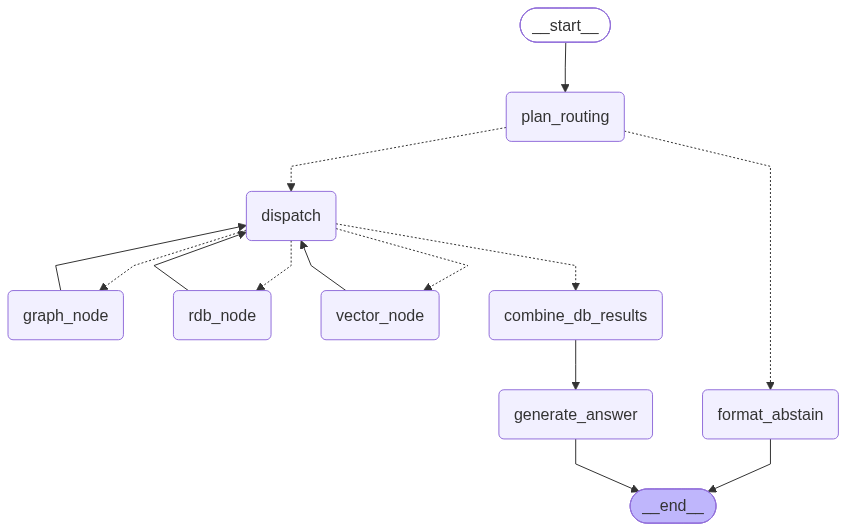

graph.png로 저장됨


In [5]:
from IPython.display import Image, display

try:
    png_bytes = g.draw_mermaid_png()
    with open("graph.png", "wb") as f:
        f.write(png_bytes)
    display(Image(png_bytes))
    print("graph.png로 저장됨")
except Exception as e:
    print("PNG 렌더링 실패 (인터넷 연결 또는 방화벽 문제일 수 있음):", e)
    print("위쪽의 mermaid 텍스트나 draw_ascii() 결과를 대신 쓰시면 됩니다.")

## 6. 실제 파이프라인 실행 (plan_routing부터 각 노드 출력 확인)

1, 2단계를 거쳤다고 가정한 고정 입력을 그대로 넣고, 실제 CLOVA X와 실제
RDB/Graph API에 진짜로 요청을 보내서 plan_routing부터 generate_answer까지
전부 돌립니다. 노드가 하나씩 끝날 때마다 그 노드가 정확히 무엇을 반환했는지
바로 아래에 출력하므로, "우리가 생각한 출력대로 나오는지"를 노드 단위로
확인할 수 있습니다.

이 아래 셀들은 더미 키가 아니라 실제 `CLOVASTUDIO_API_KEY`와 실제 서버
접속이 필요합니다.

In [3]:
# 1, 2단계를 거치고 이 형식으로 입력이 들어온다고 가정
fixed_input = {
    "question_id": "q001",
    "question": "안전한 ETF 추천해줘",
    "decomposed_conditions": [
        "위험등급 5~6등급",
        "레버리지 1배, 인버스 아님",
        "순자산 상위 정렬",
        "총보수 낮은 순 정렬",
        "안전/저위험 투자전략 관련 문서",
    ],
    "metadata_context": [
        {
            "name": "fp:riskGrade",
            "description": "위험등급. 1=최고위험, 6=최저위험. 숫자 클수록 안전. 저장: Graph(ABox). 도메인: ETF.",
        },
        {
            "name": "fp:leverageFactor",
            "description": "배수. 1=일반, 2+=레버리지, 음수=인버스. 저장: Graph(ABox). 도메인: ETF.",
        },
        {
            "name": "raw.etf_master.total_expense_ratio",
            "description": "총보수(퍼센트). 낮을수록 유리. 저장: RDB(raw 스키마). 컬럼: ter.",
        },
    ],
}
print("고정 입력 준비 완료")

고정 입력 준비 완료


### 6-1. 진짜 API 키가 로드됐는지 확인

맨 위 1번 셀에서 시각화 전용 더미 키를 `setdefault`로 넣어뒀습니다.
`setdefault`는 이미 값이 있으면 안 건드리는데, `.env`를 아직 안 읽은
시점에 더미 키가 먼저 박혀버리면 그 뒤에 `.env`를 읽어도 진짜 키로
안 바뀝니다(`load_dotenv()`는 기본적으로 이미 있는 값을 덮어쓰지
않습니다). 그래서 여기서 `override=True`로 다시 한번 읽어서 진짜 키가
있으면 그걸로 확실히 바꿔줍니다.

In [4]:
import os

try:
    from dotenv import load_dotenv
    load_dotenv(override=True)  # .env에 진짜 키가 있으면 더미 키를 덮어쓴다
except ImportError:
    pass

key = os.environ.get("CLOVASTUDIO_API_KEY", "")
if not key or key == "dummy-key-for-graph-visualization-only":
    print("경고: CLOVASTUDIO_API_KEY가 실제 키로 설정되지 않았습니다.")
    print(".env 파일에 CLOVASTUDIO_API_KEY=발급받은키 를 넣고 커널을 재시작한 뒤 다시 실행해주세요.")
else:
    print("CLOVASTUDIO_API_KEY 설정 확인됨 (실제 키로 보입니다)")

CLOVASTUDIO_API_KEY 설정 확인됨 (실제 키로 보입니다)


### 6-2. 엔진 접속 확인과 schema_hint 준비

`engines`는 위쪽 2번 셀에서 이미 만들어져 있습니다. 실제로 RDB 서버가
살아있는지 `/health`로 먼저 확인하고, `build_schema_hint`로 실제 테이블/
컬럼 목록을 가져옵니다. 이 두 개가 실패하면 그 아래 실행도 의미가 없으니
여기서 먼저 걸러냅니다.

In [5]:
from agent.engines import build_schema_hint

health = await engines.rdb.health_check()
print("RDB 서버 상태:", health)

schema_hint = await build_schema_hint(engines.rdb)
print("\nschema_hint:")
print(schema_hint)

RDB 서버 상태: {'status': 'ok', 'database': 'connected', 'clova_configured': False, 'llm_provider': 'gemini', 'llm_configured': True, 'graph': '1,016,756 triples'}

schema_hint:
- raw.prbd01n001(pd_no, pd_exg_mkt, pd_nm, pd_abrv_nm, pd_eng_nm, pd_abrv_eng_nm, pd_ctry_cd, pd_pbcm, std_pd_mcls_nm, std_pd_scls_nm, bd_knd, curr_cd, isu_bal_amt, isu_dt, mat_dt, srfc_irt, pd_evco_crd_grd, pd_risk_gcd, pd_std_info_update, buy_yield, corp_pretax_yield, corp_after_tax_yield, after_tax_yield, pref_tax_yield, avg_annual_tax_yield, depo_equiv_yield_154, buyable_quantity, remaining_days, dur, cov, ndy_dur, ndy_cov, eval_price, applied_yield, dirty, ndy_eval_price, ndy_applied_yield, ndy_dirty, crd_grd, crd_grd_dt, source_table, source_file, snapshot_date)
- raw.pref01n001(cu_base_index, cu_charge_etc_rt, cu_charge_rt, cu_fund_mgmt_co, cu_lev_fector, cu_strtegy, cu_upt_dt, du_bpr, du_chas_errt, du_clpr, du_diff_rt, du_er_1d, du_er_1m, du_er_1y, du_er_3m, du_er_6m, du_er_ytd, du_hpr, du_last_aum, du_last

### 6-3. 그래프 실행, 노드별 출력 확인

`app.astream(..., stream_mode="updates")`를 쓰면 노드 하나가 끝날 때마다
그 노드가 반환한 값만 바로 받을 수 있습니다. `ainvoke`처럼 맨 끝에 최종
결과만 한 번에 받는 것과 달리, plan_routing이 만든 execution_plan이
정확한지, graph_node/rdb_node/vector_node가 병렬로 도는지 순차로 도는지,
각 단계가 실제로 어떤 데이터를 받아왔는지를 순서대로 볼 수 있습니다.

dispatch 노드는 상태를 바꾸지 않는 빈 노드라서(`return {}`), LangGraph가
이 경우 업데이트를 `None`으로 보고합니다. 실제로 아무것도 안 바뀐 게
맞기 때문에 아래 코드에서는 이런 업데이트는 건너뜁니다.

In [6]:
app = build_graph(engines)

initial_state = {
    **fixed_input,
    "schema_hint": schema_hint,
    "step_results": {},
    "think_trace": [],
}

# think_trace, step_results는 리듀서가 있어서 단순 덮어쓰기가 아니라 병합해야
# state.py에 정의된 것과 같은 방식으로 최종 상태가 만들어진다.
final_state = dict(initial_state)

print("=== 노드별 실행 결과 (실행된 순서대로) ===\n")
async for update in app.astream(initial_state, config={"recursion_limit": 30}, stream_mode="updates"):
    for node_name, node_output in update.items():
        if not node_output:  # dispatch처럼 아무 것도 안 바뀐 노드
            continue
        print(f"--- {node_name} ---")
        for key, value in node_output.items():
            print(f"  {key}: {value}")
        print()

        if "think_trace" in node_output:
            final_state["think_trace"] = final_state.get("think_trace", []) + node_output["think_trace"]
        if "step_results" in node_output:
            final_state["step_results"] = {**final_state.get("step_results", {}), **node_output["step_results"]}
        for key, value in node_output.items():
            if key not in ("think_trace", "step_results"):
                final_state[key] = value

=== 노드별 실행 결과 (실행된 순서대로) ===

--- plan_routing ---
  execution_plan: [{'id': 'A', 'engine': 'graph', 'query': 'SELECT ?id WHERE { ?id a fp:ETF . ?id fp:riskGrade ?riskGrade . FILTER(xsd:integer(?riskGrade) >= 5 && xsd:integer(?riskGrade) <= 6) }', 'depends_on': []}, {'id': 'B', 'engine': 'rdb', 'query': 'SELECT * FROM raw.pref01n001 WHERE pd_risk_cd BETWEEN 5 AND 6 ORDER BY pd_risk_cd ASC, ter ASC', 'depends_on': ['A']}]
  query_type: 유형2_Graph순차RDB
  think_trace: ["실행 계획 2단계 생성: ['A', 'B']"]

--- graph_node ---
  step_results: {'A': {'id': 'A', 'engine': 'graph', 'ok': False, 'error': 'Graph API 에러: Client error \'400 Bad Request\' for url \'http://40.82.145.44:8000/db\'\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/400\n서버 응답 상세: {"detail":"SPARQL 실행에 실패했습니다: HTTPStatusError: Client error \'400 Bad Request\' for url \'http://graph:7878/query\'"}', 'elapsed_ms': 28.503958999863244}}
  think_trace: ["graph_node 실행: ['A']"]

--- rdb_node ---
  ste

### 6-4. 최종 결과 요약

위에서 노드별로 누적한 `final_state`가 실제로 `ainvoke`를 썼을 때와
같은 값인지는 이미 가짜 데이터로 검증해봤습니다(리듀서 병합까지
동일하게 재현). 여기서는 그중 핵심만 뽑아서 보기 좋게 정리합니다.

In [7]:
print("query_type:", final_state.get("query_type"))
print()
print("execution_plan:")
for step in final_state.get("execution_plan", []):
    print(" ", step)
print()
print("answer:", final_state.get("answer"))
print()
print("evidence:", final_state.get("evidence"))
print()
print("think_trace (실행 순서대로 쌓인 로그):")
for line in final_state.get("think_trace", []):
    print(" -", line)

query_type: 유형4_Graph다단계순차

execution_plan:
  {'id': 'A', 'engine': 'graph', 'query': 'SELECT ?etf WHERE { ?etf a fp:ETF . ?etf fp:riskGrade ?riskGrade . FILTER(?riskGrade >= 5 && ?riskGrade <= 6) }', 'depends_on': []}
  {'id': 'B', 'engine': 'graph', 'query': 'SELECT ?etf WHERE { ?etf a fp:ETF . ?etf fp:leverageFactor ?leverageFactor . FILTER(?leverageFactor = 1 && NOT EXISTS { ?etf fp:negativeLeverage ?negativeLeverage }) }', 'depends_on': ['A']}
  {'id': 'C', 'engine': 'rdb', 'query': "SELECT * FROM raw.prbd01n001 WHERE pd_risk_gcd BETWEEN '5' AND '6' AND cu_lev_fector = '1'", 'depends_on': ['B']}

answer: 죄송합니다, 현재 제공된 근거 데이터를 기반으로 안전한 ETF를 추천드릴 수 없습니다.

evidence: []

think_trace (실행 순서대로 쌓인 로그):
 - 실행 계획 3단계 생성: ['A', 'B', 'C']
 - graph_node 실행: ['A']
 - graph_node 실행: ['B']
 - rdb_node 실행: ['C']
 - 결과 통합 완료. 성공 2건, 실패 1건
 - 답변 생성 완료
